Step1: Data cleaning and binarization

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import ast
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# 1. read data
file_path = '/content/drive/MyDrive/applying data science/300 Samples Labelled1.xlsx'
df = pd.read_excel(file_path)

In [ ]:
# 2. Define a function to convert string-formatted sets "{'A', 'B'}" into Python lists ['A', 'B']
def parse_set_string(val):
    try:
        # Return an empty list if the value is NaN or an empty string
        if pd.isna(val) or val == '':
            return []
        # Use ast.literal_eval to safely evaluate the string as a Python list
        return list(ast.literal_eval(val))
    except:
        return []


In [ ]:
# 3. Apply the parsing function to the target columns
target_cols = ['thematic_primary_category', 'beneficiary_primary_group', 'organisational_role_type']
for col in target_cols:
    df[col] = df[col].apply(parse_set_string)

In [ ]:
# 4. Perform MultilabelBinarization
def binarize_column(dataframe, col_name):
    mlb = MultiLabelBinarizer()
    # Fit the data and transform into a 0/1 matrix
    encoded_data = mlb.fit_transform(dataframe[col_name])
    # Create a new DataFrame with column names prefixed by the original column name
    encoded_df = pd.DataFrame(encoded_data, columns=[f"{col_name}_{c}" for c in mlb.classes_])
    return encoded_df


In [ ]:
# Process each set column individually
df_what = binarize_column(df, 'thematic_primary_category')
df_who = binarize_column(df, 'beneficiary_primary_group')
df_how = binarize_column(df, 'organisational_role_type')

In [ ]:
# 5. One-Hot encode Geographic scope
geo_encoder = OneHotEncoder(sparse_output=False)
geo_encoded = geo_encoder.fit_transform(df[['geographic_scope_category']])
geo_cols = [f"geo_{c}" for c in geo_encoder.get_feature_names_out(['geographic_scope_category'])]
df_geo = pd.DataFrame(geo_encoded, columns=geo_cols)

In [ ]:
# 5. Combine numerical columns with the new binarized features
final_df = pd.concat([df, df_what, df_who, df_how, df_geo], axis=1)

In [ ]:
# Print completion message and preview the result
print(f"riginal number of columns: {df.shape[1]}")
print(f"Total features after binarization: {final_df.shape[1]}")
print("\nFirst 5 rows preview (including some binarized columns):")
print(final_df.head())

riginal number of columns: 15
Total features after binarization: 47

First 5 rows preview (including some binarized columns):
   organisation_number geographic_scope_category  \
0              4026952             International   
1              5043843             International   
2              5160937             International   
3              5219192             International   
4              5036731             International   

                           thematic_primary_category  \
0  [General Charitable Purposes, Disability, Recr...   
1  [Human Rights/religious Or Racial Harmony/equa...   
2                               [Education/training]   
3  [Other Charitable Purposes, The Prevention Or ...   
4  [The Prevention Or Relief Of Poverty, Overseas...   

                           beneficiary_primary_group  \
0                         [People With Disabilities]   
1                            [Children/young People]   
2                            [Children/young People]   


In [ ]:
# Save the processed data for the next step
final_df.to_csv('processed_step_1.csv', index=False)

Step2 : Feature engineering

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [ ]:
# 1. Select features for calculation
# We pick numerical columns and all new binary columns
numerical_features = ['organisational_age', 'latest_income', 'operating_margin', 'reporting_noncompliance']
binary_cols = [col for col in final_df.columns if
        col.startswith('thematic_primary_category_') or
        col.startswith('beneficiary_primary_group_') or
        col.startswith('organisational_role_type_')]

# Combine them into a feature matrix X
X = final_df[numerical_features + binary_cols].copy()


In [ ]:
# 2. Missing values imputation
# Fill them with the median.
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=X.columns)

In [ ]:
# 3. Log transformation for 'latest_income'
# Use log1p (log(1+x)) to avoid issues with zero values
X['latest_income'] = np.log1p(X['latest_income'])

In [ ]:
# 4. Standardization
# This makes every feature have a mean of 0 and a standard deviation of 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape of the scaled feature matrix: {X_scaled.shape}")

Shape of the scaled feature matrix: (300, 32)


Step3: Dimensionality reduction

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
# 1. Initialize PCA to analyze all components first
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

In [ ]:
# 2. Calculate cumulative explained variance
# See how many components are needed to represent the data
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

In [ ]:
# 3. Determine the number of components to keep (% of variance)
# 85% is a standard threshold to retain most information while removing noise
n_components = np.argmax(cumulative_variance >= 0.85) + 1

In [ ]:
# 4. PCA
pca_final = PCA(n_components=n_components)
X_pca = pca_final.fit_transform(X_scaled)

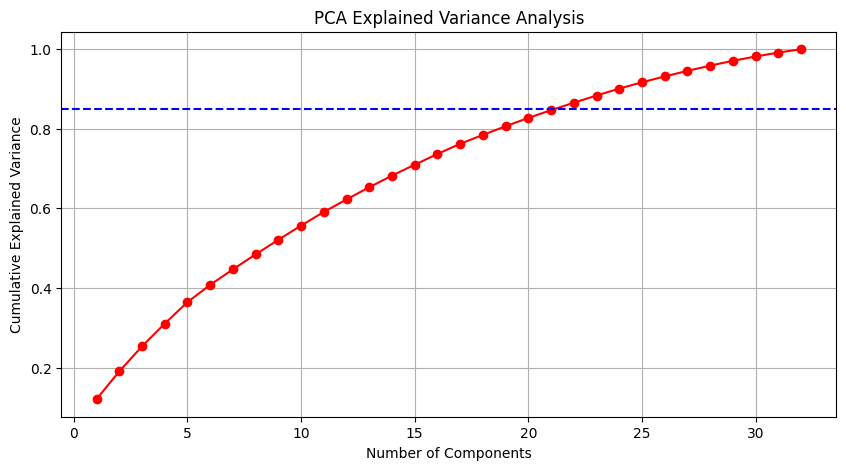

In [ ]:
# Visualization
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-')
plt.axhline(y=0.85, color='b', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance Analysis')
plt.grid(True)
plt.show()


In [ ]:
print(f"PCA Process Completed.")
print(f"Original feature count: {X_scaled.shape[1]}")
print(f"Reduced feature count: {n_components}")
print(f"Variance retained: {cumulative_variance[n_components-1]:.2%}")

PCA Process Completed.
Original feature count: 32
Reduced feature count: 22
Variance retained: 86.56%


/tmp/ipykernel_3726/4259045242.py:14: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bx-" (-> marker='x'). The keyword argument will take precedence.
  plt.plot(K_range, inertia, 'bx-', marker='s')


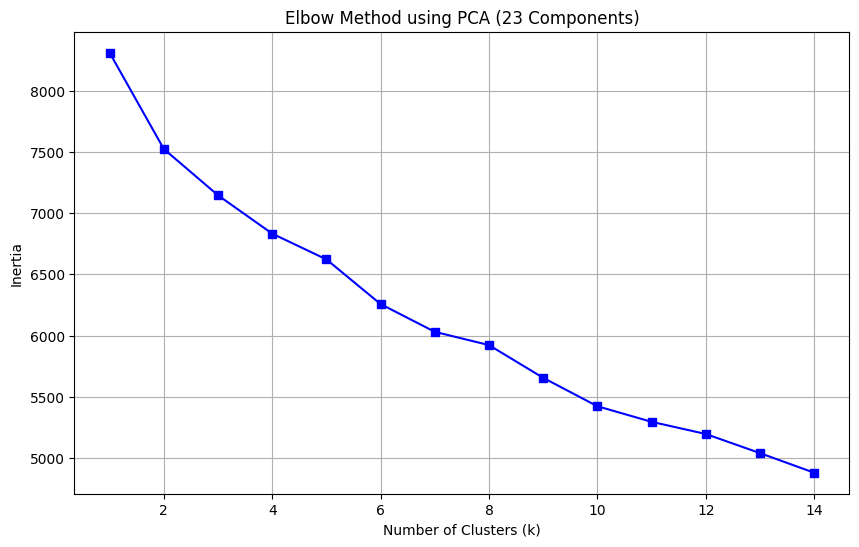

In [ ]:
# Determine K value using elbow method
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 15)

for k in K_range:
    # Use n_init=10 to ensure stability
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bx-', marker='s')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method using PCA (23 Components)')
plt.grid(True)
plt.show()

In [ ]:
# 5. UMAP
# We take the PCA results and project them into a 2D space for optimal clustering since we can't find a clearly inflection point
# n_neighbors: balancing local vs global structure (the bigger the number is, the more the points group together)
# min_dist: controls how tightly points are grouped (the smaller the number is, the tighter the clusters are)
import umap
umap_reducer = umap.UMAP(n_neighbors=5,
                         min_dist=0.0,
                         n_components=2,
                         random_state=42,
                         n_jobs=1)

X_umap = umap_reducer.fit_transform(X_pca)

print("UMAP Projection Completed. Data is now in 2D space.")

UMAP Projection Completed. Data is now in 2D space.


/tmp/ipykernel_3726/758959925.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_umap[:, 0], X_umap[:, 1], s=30, alpha=0.6, cmap='Spectral')


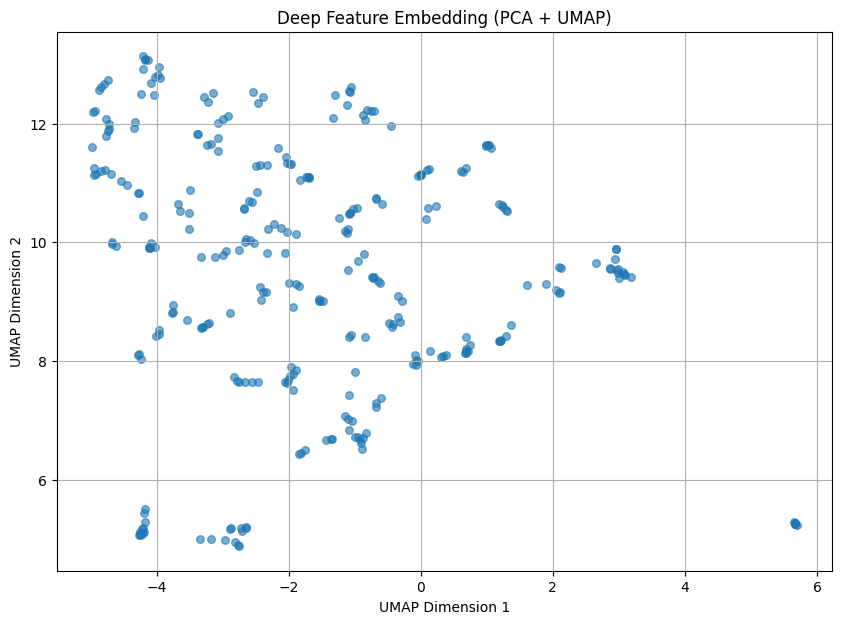

In [ ]:
# Visualization
plt.figure(figsize=(10, 7))
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=30, alpha=0.6, cmap='Spectral')
plt.title('Deep Feature Embedding (PCA + UMAP)')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.grid(True)
plt.show()

/tmp/ipykernel_3726/1134728231.py:12: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "ro-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(K_range, inertia_umap, 'ro-', marker='o')


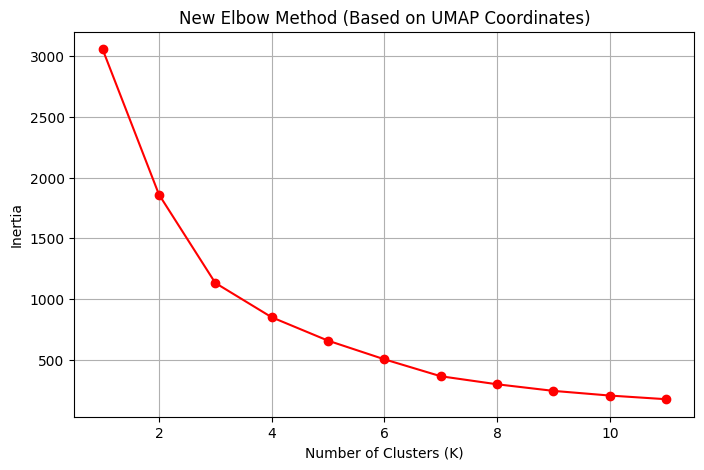

In [ ]:
# Using umap for elbow method
inertia_umap = []
K_range = range(1, 12)

for k in K_range:
    # Notice we are fitting on X_umap now, not X_pca
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_umap)
    inertia_umap.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_umap, 'ro-', marker='o')
plt.title('New Elbow Method (Based on UMAP Coordinates)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

Step 4 : Clustering

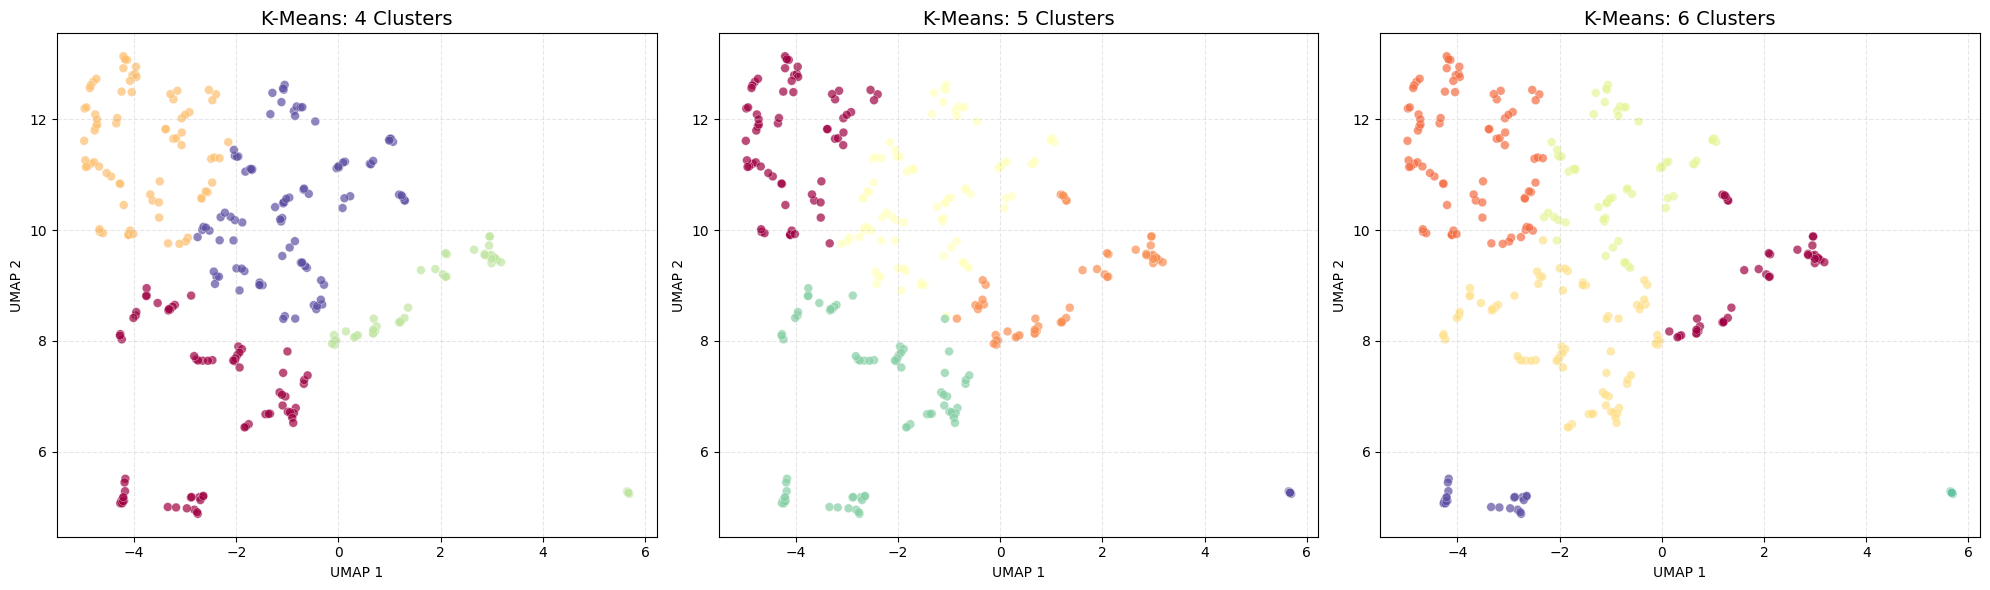

In [ ]:
# Compare possible K-Means
k_values = [4, 5, 6]

plt.figure(figsize=(20, 6))

for i, k in enumerate(k_values):
   # Clustering on UMAP coordinates
   km = KMeans(n_clusters=k, random_state=42, n_init=10)
   labels = km.fit_predict(X_umap)
   # Visualization
   plt.subplot(1, 3, i + 1)
   scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1],
               c=labels, cmap='Spectral', s=40, alpha=0.7,
               edgecolors='white', linewidth=0.3)
   plt.title(f'K-Means: {k} Clusters', fontsize=14)
   plt.xlabel('UMAP 1')
   plt.ylabel('UMAP 2')
   plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# K=4
final_k_4 = 4
kmeans_4 = KMeans(n_clusters=final_k_4, random_state=42, n_init=10)
df['Cluster_K4'] = kmeans_4.fit_predict(X_umap)
counts4 = df['Cluster_K4'].value_counts().sort_index()
# Cluster profiling
profile_k4 = df.groupby('Cluster_K4').mean(numeric_only=True)

print("--- K=4 Cluster Sizes ---")
print(df['Cluster_K4'].value_counts().sort_index())
print("\n--- K=4 Cluster Profiles (Means) ---")
display(profile_k4)

--- K=4 Cluster Sizes ---
Cluster_K4
0    75
1    78
2    50
3    97
Name: count, dtype: int64

--- K=4 Cluster Profiles (Means) ---


,organisation_number,revenue_concentration_index,organisational_age,latest_income,reporting_noncompliance,regulatory_action,operating_margin,maturity_index,compliance_risk_score,number_of_employee
Cluster_K4,,,,,,,,,,
0,4.655180e+06,0.881019,10.973333,2.525266e+05,0.160000,0.0,-0.773664,-0.578535,0.160000,19.857143
1,3.135416e+06,0.835314,27.269231,1.310005e+06,0.000000,0.0,-0.058262,0.215709,0.000000,56.153846
2,3.340270e+06,0.609010,23.880000,1.061705e+06,0.060000,0.0,-0.210751,0.139768,0.060000,84.111111
3,3.618325e+06,0.675415,22.958763,1.699240e+06,0.010309,0.0,0.026282,0.201819,0.010309,89.592593


In [ ]:
# K=5
final_k_5 = 5
kmeans_5 = KMeans(n_clusters=final_k_5, random_state=42, n_init=10)
df['Cluster_K5'] = kmeans_5.fit_predict(X_umap)
counts5 = df['Cluster_K5'].value_counts().sort_index()
# Cluster profiling
profile_k5 = df.groupby('Cluster_K5').mean(numeric_only=True)

# check the sizes
print("--- K=5 Cluster Sizes ---")
print(df['Cluster_K5'].value_counts().sort_index())
print("\n--- K=5 Cluster Profiles (Means) ---")
display(profile_k5)

--- K=5 Cluster Sizes ---
Cluster_K5
0    66
1    56
2    95
3    76
4     7
Name: count, dtype: int64

--- K=5 Cluster Profiles (Means) ---


,organisation_number,revenue_concentration_index,organisational_age,latest_income,reporting_noncompliance,regulatory_action,operating_margin,maturity_index,compliance_risk_score,number_of_employee,Cluster_K4
Cluster_K5,,,,,,,,,,,
0,2.786604e+06,0.871412,30.939394,1.445823e+06,0.000000,0.0,-0.074385,0.320872,0.000000,74.888889,1.000000
1,3.761884e+06,0.599187,19.964286,5.777930e+05,0.035714,0.0,-0.091552,-0.018324,0.035714,50.454545,2.232143
2,3.684312e+06,0.686676,21.894737,1.739199e+06,0.010526,0.0,0.040572,0.172732,0.010526,83.888889,2.747368
3,4.660072e+06,0.887455,11.013158,2.576150e+05,0.157895,0.0,-0.763235,-0.567547,0.157895,18.750000,0.039474
4,1.847944e+06,0.669840,42.000000,3.778291e+06,0.142857,0.0,-0.909946,0.938950,0.142857,401.000000,2.000000


In [ ]:
# K=6
final_k_6 = 6
kmeans_6 = KMeans(n_clusters=final_k_6, random_state=42, n_init=10)
df['Cluster_K6'] = kmeans_6.fit_predict(X_umap)
counts6 = df['Cluster_K6'].value_counts().sort_index()
# Cluster profiling
profile_k6 = df.groupby('Cluster_K6').mean(numeric_only=True)

# check the sizes
print("--- K=6 Cluster Sizes ---")
print(df['Cluster_K6'].value_counts().sort_index())
print("\n--- K=6 Cluster Profiles (Means) ---")
display(profile_k6)

--- K=6 Cluster Sizes ---
Cluster_K6
0    43
1    82
2    80
3    65
4     7
5    23
Name: count, dtype: int64

--- K=6 Cluster Profiles (Means) ---


,organisation_number,revenue_concentration_index,organisational_age,latest_income,reporting_noncompliance,regulatory_action,operating_margin,maturity_index,compliance_risk_score,number_of_employee,Cluster_K4,Cluster_K5
Cluster_K6,,,,,,,,,,,,
0,3.682167e+06,0.591896,20.767442,6.883189e+05,0.046512,0.0,-0.147041,0.022012,0.046512,64.625000,2.116279,1.000000
1,3.216552e+06,0.846931,26.597561,1.252907e+06,0.000000,0.0,-0.058576,0.185336,0.000000,52.357143,1.121951,0.390244
2,4.334899e+06,0.769221,14.287500,8.555747e+05,0.000000,0.0,-0.717524,-0.413555,0.000000,76.111111,0.987500,2.500000
3,3.488386e+06,0.632851,24.630769,1.461824e+06,0.015385,0.0,0.044341,0.264702,0.015385,87.222222,2.969231,2.000000
4,1.847944e+06,0.669840,42.000000,3.778291e+06,0.142857,0.0,-0.909946,0.938950,0.142857,401.000000,2.000000,4.000000
5,4.483867e+06,0.861191,11.260870,7.296853e+05,0.521739,0.0,0.063389,-0.297306,0.521739,23.166667,0.000000,3.000000


In [ ]:
# Test

print("--- Distribution for K=4 ---")
print(counts4.values)
print("\n--- Distribution for K=5 ---")
print(counts5.values)
print("\n--- Distribution for K=6 ---")
print(counts6.values)


--- Distribution for K=4 ---
[75 78 50 97]

--- Distribution for K=5 ---
[66 56 95 76  7]

--- Distribution for K=6 ---
[43 82 80 65  7 23]


In [ ]:
# Data
results = {
    'K=4': [88, 72, 91, 49],
    'K=5': [64, 45, 71, 48, 72],
    'K=6': [46, 45, 50, 47, 71, 41]
}

balance_report = []

for k_name, counts in results.items():
    counts_array = np.array(counts)
    gap = counts_array.max() - counts_array.min()
    std_dev = counts_array.std() # Measures how much sizes vary from the average

    balance_report.append({
        'Clusters': k_name,
        'Min Size': counts_array.min(),
        'Max Size': counts_array.max(),
        'Gap (Range)': gap,
        'Balance Score (StdDev)': round(std_dev, 2)
    })

# Display the comparison
balance_df = pd.DataFrame(balance_report)
print("--- Mathematical Balance Comparison ---")
display(balance_df)

--- Mathematical Balance Comparison ---


,Clusters,Min Size,Max Size,Gap (Range),Balance Score (StdDev)
0,K=4,49,91,42,16.66
1,K=5,45,72,27,11.40
2,K=6,41,71,30,9.76


In [ ]:
# 1. Define the mapping
segment_map = {
    0: "Community-Scale Operators",
    1: "Established Mid-Tier Entities",
    2: "High-Growth / At-Risk Segment",
    3: "Institutional Tier-1 NGOs"
}

# 2. Apply the labels
df['Strategic_Archetype'] = df['Cluster_K4'].map(segment_map)

# 3. Summary table
strategic_table = df.groupby('Strategic_Archetype').agg({
    'latest_income': 'mean',
    'organisational_age': 'mean',
    'number_of_employee': 'mean',
    'reporting_noncompliance': 'mean'
}).reset_index()

# 4. Professional Formatting
strategic_table.columns = [
    'Strategic Archetype', 'Avg Income (£)', 'Avg Age (Yrs)', 'Avg Staff Count', 'Non-Compliance Rate'
]

# 4. Display
print("--- Strategic Segment Classification Table ---")
display(strategic_table.sort_values(by='Avg Income (£)'))

--- Strategic Segment Classification Table ---


,Strategic Archetype,Avg Income (£),Avg Age (Yrs),Avg Staff Count,Non-Compliance Rate
0,Community-Scale Operators,2.525266e+05,10.973333,19.857143,0.160000
2,High-Growth / At-Risk Segment,1.061705e+06,23.880000,84.111111,0.060000
1,Established Mid-Tier Entities,1.310005e+06,27.269231,56.153846,0.000000
3,Institutional Tier-1 NGOs,1.699240e+06,22.958763,89.592593,0.010309


In [ ]:
# 1. Define the Strategic Archetypes for K=5
segment_map_k5 = {
    0: "Emerging Service Providers",
    1: "Small established Foundations",
    2: "Established Mid-Tier Entities",
    3: "Institutional Tier-1 NGOs",
    4: "High-Growth / At-Risk Segment"
}

# 2. Apply the mapping
df['Strategic_Archetype_K5'] = df['Cluster_K5'].map(segment_map_k5)

# 3. Summary table
strategic_table_k5 = df.groupby('Strategic_Archetype_K5').agg({
    'latest_income': 'mean',
    'organisational_age': 'mean',
    # Using the long name from your data for Staff/Employee counts
    'number_of_employee': 'mean',
    # Using the column that contains the 0.125 / 0.06 type values for risk
    'reporting_noncompliance': 'mean'
}).reset_index()

# 4. Professional Formatting
strategic_table_k5.columns = [
    'Strategic Archetype', 'Avg Income (£)', 'Avg Age (Yrs)', 'Avg Staff Count', 'Non-Compliance Rate'
]

# Convert rate to percentage for the report
strategic_table_k5['Non-Compliance Rate'] = strategic_table_k5['Non-Compliance Rate'].apply(lambda x: f"{x*100:.1f}%")
pd.options.display.float_format = '{:,.2f}'.format

# 5. Display
display(strategic_table_k5.sort_values(by='Avg Income (£)'))

,Strategic Archetype,Avg Income (£),Avg Age (Yrs),Avg Staff Count,Non-Compliance Rate
3,Institutional Tier-1 NGOs,"257,615.01",11.01,18.75,15.8%
4,Small established Foundations,"577,792.98",19.96,50.45,3.6%
0,Emerging Service Providers,"1,445,822.73",30.94,74.89,0.0%
1,Established Mid-Tier Entities,"1,739,198.92",21.89,83.89,1.1%
2,High-Growth / At-Risk Segment,"3,778,291.29",42.00,401.00,14.3%


In [ ]:
# 1. Define the Strategic Archetypes for K=6
segment_map_k6 = {
    0: "Emerging Service Providers",
    1: "Small-Scale Foundations",
    2: "Established Efficiency-Focused",
    3: "Tier-1 Institutional NGOs",
    4: "High-Growth / At-Risk Segment",
    5: "Mature Professional Mid-Tier"
}

# 2. Apply the mapping
df['Strategic_Archetype_K6'] = df['Cluster_K6'].map(segment_map_k6)

# 3. Create the summary table
strategic_table_k6 = df.groupby('Strategic_Archetype_K6').agg({
    'latest_income': 'mean',
    'organisational_age': 'mean',
    'number_of_employee': 'mean',
    'reporting_noncompliance': 'mean'
}).reset_index()

# 4. Professional Formatting
strategic_table_k6.columns = [
    'Strategic Archetype', 'Avg Income (£)', 'Avg Age (Yrs)', 'Avg Staff Count', 'Non-Compliance Rate'
]

# Formatting for the report
strategic_table_k6['Non-Compliance Rate'] = strategic_table_k6['Non-Compliance Rate'].apply(lambda x: f"{x*100:.1f}%")
pd.options.display.float_format = '{:,.2f}'.format

# 5. Display the table
print("--- Strategic Segment Classification Table (K=6) ---")
display(strategic_table_k6.sort_values(by='Avg Income (£)'))

--- Strategic Segment Classification Table (K=6) ---


,Strategic Archetype,Avg Income (£),Avg Age (Yrs),Avg Staff Count,Non-Compliance Rate
0,Emerging Service Providers,"688,318.91",20.77,64.62,4.7%
3,Mature Professional Mid-Tier,"729,685.35",11.26,23.17,52.2%
1,Established Efficiency-Focused,"855,574.68",14.29,76.11,0.0%
4,Small-Scale Foundations,"1,252,906.51",26.60,52.36,0.0%
5,Tier-1 Institutional NGOs,"1,461,824.02",24.63,87.22,1.5%
2,High-Growth / At-Risk Segment,"3,778,291.29",42.00,401.00,14.3%


In [ ]:
df['Cluster4'] = kmeans_4.fit_predict(X_umap)
# The most common sectors inside K = 4 cluster
for i in range(4):
    print(f"--- Dominant Activities in Cluster {i} ---")

    # We look at the 'thematic_primary_category' column for organizations in this cluster
    # Change 'thematic_primary_category' to 'apriori_profile' if that column is more descriptive
    top_sectors = df[df['Cluster4'] == i]['thematic_primary_category'].value_counts().head(4)
    print(top_sectors)
    print("-" * 30)

--- Dominant Activities in Cluster 0 ---
thematic_primary_category
[Religious Activities]                                 9
[Religious Activities, General Charitable Purposes]    6
[General Charitable Purposes]                          6
[Animals]                                              6
Name: count, dtype: int64
------------------------------
--- Dominant Activities in Cluster 1 ---
thematic_primary_category
[Arts/culture/heritage/science, Education/training]    13
[Education/training]                                   10
[General Charitable Purposes]                           7
[Arts/culture/heritage/science]                         6
Name: count, dtype: int64
------------------------------
--- Dominant Activities in Cluster 2 ---
thematic_primary_category
[Accommodation/housing]                                                                                                                                                                   5
[The Prevention Or Relief Of Poverty,

In [ ]:
df['Cluster5'] = kmeans_5.fit_predict(X_umap)
# The most common sectors inside K = 5 cluster
for i in range(5):
    print(f"--- Dominant Activities in Cluster {i} ---")

    # We look at the 'thematic_primary_category' column for organizations in this cluster
    # Change 'thematic_primary_category' to 'apriori_profile' if that column is more descriptive
    top_sectors = df[df['Cluster5'] == i]['thematic_primary_category'].value_counts().head(5)
    print(top_sectors)
    print("-" * 30)

--- Dominant Activities in Cluster 0 ---
thematic_primary_category
[Arts/culture/heritage/science, Education/training]                                       12
[General Charitable Purposes]                                                              7
[Arts/culture/heritage/science]                                                            6
[Education/training]                                                                       5
[Environment/conservation/heritage, Arts/culture/heritage/science, Education/training]     3
Name: count, dtype: int64
------------------------------
--- Dominant Activities in Cluster 1 ---
thematic_primary_category
[The Prevention Or Relief Of Poverty, Overseas Aid/famine Relief, Education/training, Religious Activities, The Advancement Of Health Or Saving Of Lives, General Charitable Purposes]    2
[The Prevention Or Relief Of Poverty, Overseas Aid/famine Relief, Education/training, Disability, The Advancement Of Health Or Saving Of Lives, Accommodatio

In [ ]:
df['Cluster6'] = kmeans_6.fit_predict(X_umap)
# The most common sectors inside K = 6 cluster
for i in range(6):
    print(f"--- Dominant Activities in Cluster {i} ---")

    # We look at the 'thematic_primary_category' column for organizations in this cluster
    # Change 'thematic_primary_category' to 'apriori_profile' if that column is more descriptive
    top_sectors = df[df['Cluster5'] == i]['thematic_primary_category'].value_counts().head(6)
    print(top_sectors)
    print("-" * 30)

--- Dominant Activities in Cluster 0 ---
thematic_primary_category
[Arts/culture/heritage/science, Education/training]                                       12
[General Charitable Purposes]                                                              7
[Arts/culture/heritage/science]                                                            6
[Education/training]                                                                       5
[Environment/conservation/heritage, Arts/culture/heritage/science, Education/training]     3
[Environment/conservation/heritage]                                                        3
Name: count, dtype: int64
------------------------------
--- Dominant Activities in Cluster 1 ---
thematic_primary_category
[The Prevention Or Relief Of Poverty, Overseas Aid/famine Relief, Education/training, Religious Activities, The Advancement Of Health Or Saving Of Lives, General Charitable Purposes]                                                                     